# Assignment 01 (Python), Sem 2520

## Introduction

In this question, we shall investigate the strength of agreement between two raters. Suppose that two pathologists, labelled $A$ and $B$, separately classify 118 slides regarding the presence/absence and extent of carcinoma of the uterine cervix. The rating scale has the following *ordered* categories:

1. negative 
2. atypical squamous hyperplasia
3. carcinoma *in situ*
4. squamous or invasive carcinoma

The assignment here requires several numpy operations. Take the opportunity to think about the variety of ways you can perform each step; try to read up on common numpy methods that you might use here, e.g. `np.matmul`, `np.repeat` and so on.
   

In [1]:
import pandas as pd
import numpy as np
from scipy import stats

The following code will read the data in Python.

In [2]:
raters_df = pd.read_csv('data/pathologist_raters.csv')
raters_df.head()

,A,B
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1


The above excerpt indicates that in the first five slides, both raters awarded category 1.

## Agreement

Let $\pi_{ij}$ be the probability that observer $A$ labels a slide to be in category $i$ and observer $B$ rates it as category $j$, where $i,j \in \{1,2,3,4\}$. Then $\pi_{ii}$ is the probability that they both choose category $i$, and $\sum_{i} \pi_{ii}$ is the total probability of agreement. 

> Perfect agreement corresponds to $\sum_{i} \pi_{ii} = 1$

### 1. Pearson Residuals

When we covered the $\chi^2$ goodness-of-fit test, and when we created mosaic plots in R, we discussed inspecting the residuals to assess the deviation from independence. Let $n_{ij}$ be the cell count in row $i$ column $j$, and let $n$ be the total number of observations. Then the expected cell count in row $i$ column $j$ under independence is computed as:

$$
\hat{\mu}_{ij} = n \times \pi_{i+} \times \pi_{+j}
$$

The Pearson residual is computed as 
$$
r_{ij} = \frac{n_{ij} - \hat{\mu}_{ij}}{\sqrt{ \hat{\mu}_{ij} }}
$$

Create a numpy array `r` containing the Pearson residuals for the above dataset. The array should be of shape `(4,4)`.

In [3]:
# YOUR CODE HERE
raters_df.groupby(["A", "B"]).size().reset_index(name="count")
table = raters_df.groupby(["A", "B"]).size().unstack(fill_value=0)
table

B,1,2,3,4
A,,,,
1,22,2,2,0
2,5,7,14,0
3,0,2,36,0
4,0,1,17,10


Good agreement between the raters corresponds to large positive residuals on the diagonal and large negative residuals on the off-diagonals. We do indeed have this pattern for this data.

### 2. Heat map

The following code creates the heatmap below. The visualisation colour codes cells with larger counts to be a darker shade of blue, but this is done column-wise. We can see that the two most common disagreements were pathologist $B$ choosing 3 and pathologist $A$ choosing category 2 or 4.

In [4]:
pd.crosstab(raters_df['A'], raters_df['B']).style.background_gradient()

B,1,2,3,4
A,,,,
1,22,2,2,0
2,5,7,14,0
3,0,2,36,0
4,0,1,17,10


Modify the code to create this visualisation instead, which performs the colour coding *by rows instead of columns*.

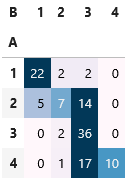

In [5]:
# YOUR CODE HERE
pd.crosstab(raters_df['A'], raters_df['B']).style.background_gradient(axis=1, subset=None)

B,1,2,3,4
A,,,,
1,22,2,2,0
2,5,7,14,0
3,0,2,36,0
4,0,1,17,10


### 3. Cohen's Kappa

Take note that *agreement* is not quite the same as *association*. Consider, for instance, if observer $B$ consistently rated slides one category higher than observer $A$. In such a situation, agreement would be low, but association would be high.

Cohen's Kappa is one measure of *agreement* that is commonly used, when there are two raters:

$$
\kappa = \frac{\sum_i \pi_{ii} - \sum_i \pi_{i+} \pi_{+i}}{1 - \sum_i \pi_{i+} \pi_{+i}}
$$

The denominator corresponds to the maximum difference between perfect agreement and agreement by chance (under independence). Compute $\kappa$ for this dataset and store it as `kappa_1`. `kappa_1` should be a `numpy` array of shape `(1,)`.

In [6]:
# YOUR CODE HERE
ct = pd.crosstab(raters_df['A'], raters_df['B'])
def cohen_kappa(crosstab):
    n = ct.to_numpy().sum()
    pi = ct / n
    observed = np.trace(pi.to_numpy())
    
    pi_row = pi.sum(axis = 1).to_numpy()
    pi_col = pi.sum(axis = 0).to_numpy()
    
    expected = np.sum(pi_row * pi_col)
    
    kappa = (observed - expected) / ( 1 - expected)
    return kappa
kappa_1 = np.array([cohen_kappa(ct)])
kappa_1

array([0.4930056])

### 4. A Pathological Case Concerning Pathlogists

The agreement measure is not perfect. Consider the following data:

In [7]:
rater_A = np.concat([np.repeat(1, 120), np.repeat(2, 5)])
rater_B = np.concat([np.repeat(1, 118), np.repeat(2, 2), np.repeat(1, 5)])
path_case = pd.DataFrame({'A': rater_A, 'B': rater_B})
pd.crosstab(path_case.A, path_case.B)

B,1,2
A,,
1,118,2
2,5,0


Intuitively it seems like agreement should be high. Compute $\kappa$ for this data and store it as `kappa_2`. Once again, `kappa_2` should have shape `(1,)`.

In [8]:
ct = pd.crosstab(path_case.A, path_case.B)
kappa_2 = np.array([cohen_kappa(ct)])
kappa_2

array([-0.02339181])

### 5. Compute weighted kappa

A more lenient criteria for agreement is to consider a weighted form of agreement. One possible set of weights is 
$$
w_{ij} = 1 -\frac{|i-j|}{I-1}
$$
where $I$ is the number of categories (in this case $I=4$). This denotes greater agreement for cells nearer the main diagonal. The formula for weighted 
$\kappa$ is 

$$
\kappa_w = \frac{\sum_{i,j} w_{ij} \pi_{ij} - \sum_{i,j} w_{ij} \pi_{i+} \pi_{+j}}{1 - \sum_{i,j} w_{ij} \pi_{i+} \pi_{+j}}
$$

Compute $\kappa_w$ for the first data (not the pathological case) and store it as `kappa_w`, again with shape `(1,)`.

In [11]:
# YOUR CODE HERE
ct = pd.crosstab(raters_df['A'], raters_df['B'])
n = ct.to_numpy().sum()
pi = ct / n
pi_np = pi.to_numpy()

I = pi.shape[0]
weights = np.zeros(pi.shape)
for i in range(I):
    for j in range(I):
        weights[i,j] = 1 - abs(i - j) / (I - 1)

pi_row = pi.sum(axis=1).to_numpy()
pi_col = pi.sum(axis=0).to_numpy()

expected = np.outer(pi_row, pi_col)

weighted_observed = np.sum(weights * pi_np)
weighted_expected = np.sum(weights * expected)

kappa_w_val = (weighted_observed - weighted_expected) / (1 - weighted_expected)
kappa_w = np.array([kappa_w_val])

array([0.64880952])

Notice that once we are more lenient about how we count agreement, the agreement measure becomes closer to 1.

## Reference

* *Categorical Data Analysis*, Agresti, A (2002), Wiley-Interscience.